# Business Problem
- A supervised machine learning regression project to predict house prices in India based on property characteristics such as location, size, number of bedrooms, bathrooms, and other housing features.
- Target: Rent

In [114]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns
from pandas.plotting import scatter_matrix
import re

In [115]:
df=pd.read_csv('Indian_House_Rent_Dataset.csv')


# Preliminary EDA 

In [116]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Posted On          4084 non-null   str  
 1   BHK                3963 non-null   str  
 2   Size               3826 non-null   str  
 3   Floor              3960 non-null   str  
 4   Area Type          3804 non-null   str  
 5   Area Locality      4146 non-null   str  
 6   City               4091 non-null   str  
 7   Furnishing Status  4042 non-null   str  
 8   Tenant Preferred   4094 non-null   str  
 9   Bathroom           4205 non-null   str  
 10  Point of Contact   4137 non-null   str  
 11  Rent               4746 non-null   int64
dtypes: int64(1), str(11)
memory usage: 907.3 KB


In [117]:
print('\n DF SHAPE:', df.shape )


 DF SHAPE: (4746, 12)


In [118]:
df.head()

,Posted On,BHK,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,Rent
0,NaN,2.0,1100.0,NaN,Super Area,Bandel,India-! Kolkata,Unfurnished,Bach^elors/Fam.ily,2.0,Contact Owner,10000
1,2022-05-13,2.0,800.0,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",India-! Kolkata,Semi-Furnished,Bachelors\/Family*,NaN,NaN,20000
2,2022-05-16,2.0,1000.0,1 out of 3,Super Area,Salt Lake City Sector 2,India-- Kolkata,Semi-Furnished,NaN,1.0,Contact Owner,17000
3,2022-07-04,2.0,800.0,1 out of 2,Super Area,NaN,NaN,Unfurnished,Bachel]ors/F@amily,1.0,NaN,10000
4,2022-05-09,2.0 room,850.0,1 out of 2,Carpet Area,South Dum Dum,India-^ Kolkata,Unfurnished,Bache[lors&,1.0,Contact Owner,7500


In [119]:
df.isna().sum()

Posted On            662
BHK                  783
Size                 920
Floor                786
Area Type            942
Area Locality        600
City                 655
Furnishing Status    704
Tenant Preferred     652
Bathroom             541
Point of Contact     609
Rent                   0
dtype: int64

Find empty rows and drop , if missing 50% or more drop

In [120]:
df['Furnishing Status'].value_counts()

Furnishing Status
Semi-Furnished    1908
Unfurnished       1555
Furnished          579
Name: count, dtype: int64

# Cleaning

1 Posted On (probably useless)

In [121]:
df['Posted On'] = pd.to_datetime(df['Posted On'], errors='coerce')

2 BHK num of Bedrooms, Hall, and Kitchen.

In [122]:
df['BHK'].value_counts()

BHK
2.0         1886
1.0          922
3.0          893
4.0          158
2.0 room      35
1.0 room      25
3.0 room      18
5.0           15
6.0            4
4.0 room       4
5.0 room       2
6.0 room       1
Name: count, dtype: int64

In [123]:
df["BHK"]=df["BHK"].str.extract(r'(\d+)')

In [124]:
df['BHK'].value_counts()

BHK
2    1921
1     947
3     911
4     162
5      17
6       5
Name: count, dtype: int64

In [125]:
df["BHK"]=pd.to_numeric(df["BHK"])

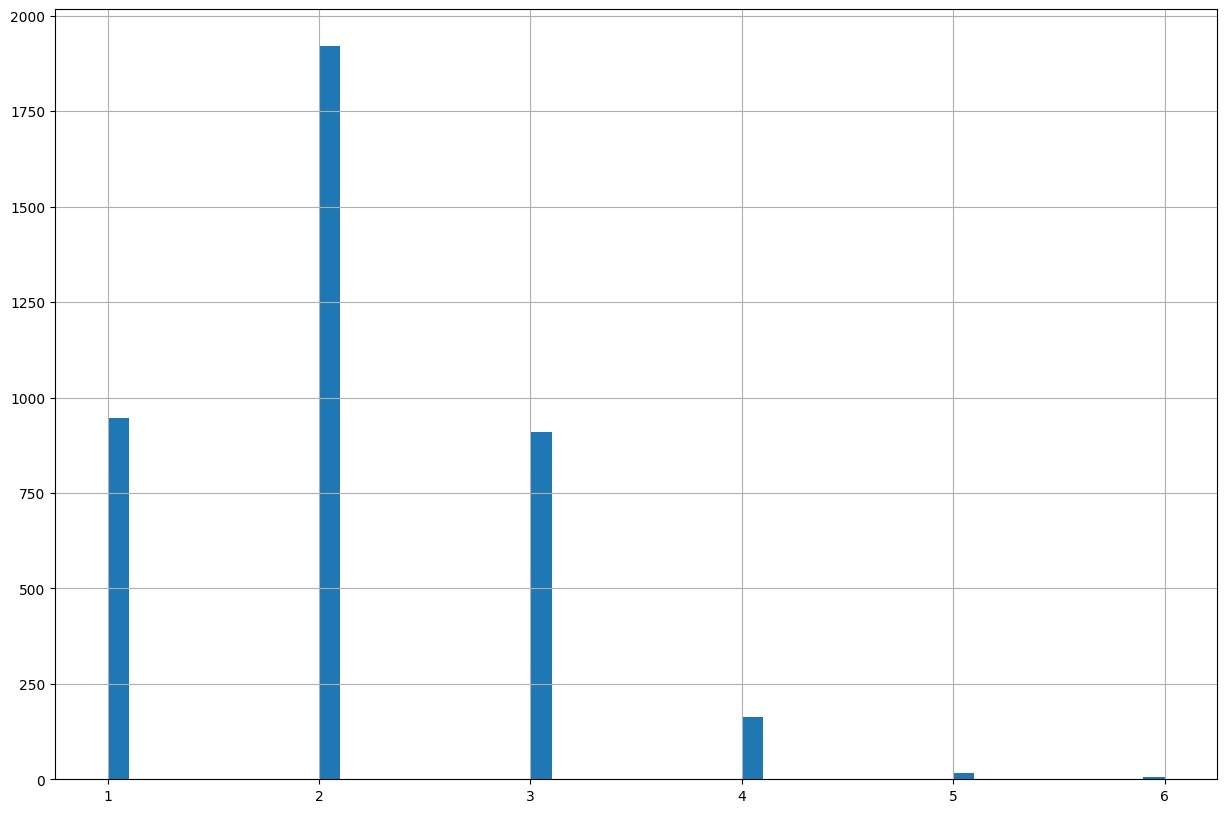

In [126]:
df['BHK'].hist(bins=50, figsize=(15,10))
plt.show()

In [127]:
df['BHK'].describe()

count    3963.000000
mean        2.090588
std         0.826504
min         1.000000
25%         2.000000
50%         2.000000
75%         3.000000
max         6.000000
Name: BHK, dtype: float64

In [128]:
df['BHK'].isna().sum()#make sure is the same

np.int64(783)

3 Size 

In [129]:
df['Size'].value_counts()

Size
1000.0    190
600.0     181
800.0     180
500.0     158
1200.0    156
         ... 
1124.0      1
4200.0      1
3250.0      1
214.0       1
855.0       1
Name: count, Length: 588, dtype: int64

In [130]:
df['Size'].unique()

<ArrowStringArray>
['1100.0',  '800.0', '1000.0',  '850.0',  '600.0',  '700.0',  '250.0',
      nan, '1200.0',  '400.0',
 ...
 '1834.0',   '10.0', '3789.0', '1160.0', '1422.0', '1124.0', '4200.0',
 '3250.0',  '214.0',  '855.0']
Length: 589, dtype: str

In [131]:
df["Size"]=df["Size"].str.extract(r'(\d+)')

df["Size"]=pd.to_numeric(df["Size"])
df['Size'].value_counts()

Size
1000.0    191
600.0     183
800.0     181
500.0     161
1200.0    158
         ... 
1124.0      1
4200.0      1
3250.0      1
214.0       1
855.0       1
Name: count, Length: 549, dtype: int64

In [132]:
df['Size'].describe()

count    3826.000000
mean      967.802405
std       627.895502
min        10.000000
25%       551.250000
50%       845.500000
75%      1200.000000
max      7000.000000
Name: Size, dtype: float64

In [133]:
df['Size'].isna().sum()

np.int64(920)

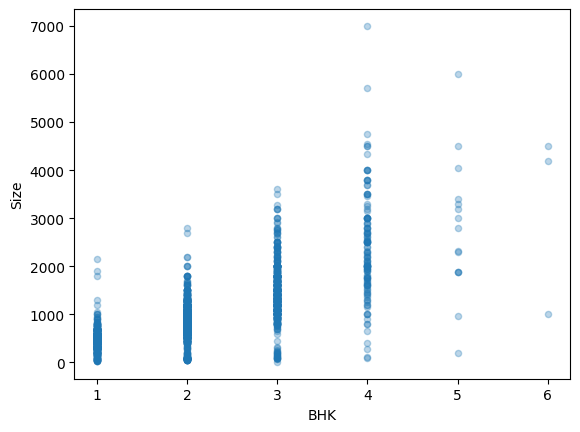

In [134]:
df.plot(kind='scatter', x='BHK', y='Size', alpha=0.3)
plt.show()

In [135]:
df[df['Size'] < 100][['BHK', 'Size']]

,BHK,Size
116,1.0,20.0
189,1.0,44.0
2425,2.0,70.0
2428,2.0,60.0
2445,2.0,48.0
...,...,...
4220,1.0,80.0
4512,1.0,67.0
4653,3.0,10.0
4706,NaN,50.0


BHK & Size Cleaning
- Extracted numeric values from text (e.g. "2.0 room" → 2.0) using regex, then converted to numeric type.
- Found 73 rows with unrealistic Size values (<100 sqft) → treated as data entry errors and set to NaN (row kept, invalid value dropped) instead of removing the rows.

In [136]:
df.loc[df['Size'] < 100, 'Size'] = np.nan

In [137]:
df['Size'].isna().sum() #expected to be 73 more

np.int64(993)

4 Floor

In [138]:
df['Floor'].value_counts()

Floor
1 out of 2                 324
Ground out of 2            278
2 out of 3                 263
2 out of 4                 263
1 out of 3                 243
                          ... 
15 out of 30                 1
12 out of 30                 1
Upper Basement out of 2      1
6 out of 13                  1
23 out of 34                 1
Name: count, Length: 433, dtype: int64

In [139]:
df['Floor'] = df['Floor'].str.replace('Ground', '0', regex=False) # replace 'Ground' with '0'
df[['Current Floor', 'Total Floors']] = df['Floor'].str.extract(r'(\d+)\s*out of\s*(\d+)')

df['Current Floor'] = pd.to_numeric(df['Current Floor'])
df['Total Floors'] = pd.to_numeric(df['Total Floors'])

In [140]:
df[['Floor', 'Current Floor', 'Total Floors']].head(10)

,Floor,Current Floor,Total Floors
0,NaN,NaN,NaN
1,1 out of 3,1.0,3.0
2,1 out of 3,1.0,3.0
3,1 out of 2,1.0,2.0
4,1 out of 2,1.0,2.0
5,0 out of 1,0.0,1.0
6,0 out of 4,0.0,4.0
7,1 out of 2,1.0,2.0
8,1 out of 2,1.0,2.0
9,1 out of 3,1.0,3.0


In [141]:
df = df.drop('Floor', axis=1)

In [142]:
df['Total Floors'].isna().sum()

np.int64(812)

In [143]:
df['Current Floor'].value_counts()

Current Floor
1.0     979
2.0     801
0.0     766
3.0     422
4.0     224
5.0     133
6.0      75
7.0      58
8.0      58
10.0     54
9.0      53
12.0     41
11.0     37
15.0     33
14.0     32
18.0     23
17.0     20
16.0     15
19.0     14
13.0     12
20.0     10
25.0      8
23.0      7
21.0      6
30.0      5
24.0      5
34.0      4
26.0      3
65.0      3
35.0      3
27.0      3
60.0      2
53.0      2
32.0      2
28.0      2
40.0      2
22.0      2
48.0      2
36.0      2
43.0      1
39.0      1
47.0      1
37.0      1
44.0      1
41.0      1
46.0      1
50.0      1
29.0      1
76.0      1
45.0      1
Name: count, dtype: int64

In [144]:
df['Total Floors'].value_counts()

Total Floors
4.0     788
3.0     764
2.0     716
5.0     346
1.0     281
       ... 
52.0      1
54.0      1
85.0      1
71.0      1
81.0      1
Name: count, Length: 63, dtype: int64

Floor Split into Current Floor and Total Floors since the original column combined both pieces of information as text  to be turned to num

5 Area Type

In [145]:
df['Area Type'].value_counts()

Area Type
Super Area     1971
Carpet Area    1799
CARPET AREA      25
SUPER AREA        7
Built Area        2
Name: count, dtype: int64

In [146]:
df['Area Type'] = df['Area Type'].str.strip().str.title()

6 Area Locality

In [147]:
df['Area Locality'].value_counts()

Area Locality
Bandra West                         34
Gachibowli                          27
Electronic City                     23
Miyapur, NH 9                       19
Chembur                             18
                                    ..
Vikrampuri, Secunderabad             1
Netaji Nagar Colony, Langar Houz     1
K P H B Phase 9                      1
Vinayaka Nagar                       1
Godavari Homes, Quthbullapur         1
Name: count, Length: 2017, dtype: int64

In [148]:
df['Area Locality'].unique()

<ArrowStringArray>
[                                 'Bandel',
                'Phool Bagan, Kankurgachi',
                 'Salt Lake City Sector 2',
                                       nan,
                           'South Dum Dum',
                             'Thakurpukur',
                                'Malancha',
         'Palm Avenue Kolkata, Ballygunge',
                                'Natunhat',
         'Action Area 1, Rajarhat Newtown',
 ...
   'Kukatpally Housing Board Colony, NH 9',
                                'Kuntloor',
 'Anandbagh, Secunderabad, Moula Ali Road',
      'Venkataramana Colony, Secunderabad',
     'Srinagar Colony, Old Malakpet, NH 9',
                'Vikrampuri, Secunderabad',
        'Netaji Nagar Colony, Langar Houz',
                         'K P H B Phase 9',
                          'Vinayaka Nagar',
            'Godavari Homes, Quthbullapur']
Length: 2018, dtype: str

In [149]:
df['Area Locality'] = df['Area Locality'].str.strip()

In [150]:
df['Area Locality'].str.contains(r'[^A-Za-z0-9\s,]').sum()

np.int64(118)

In [151]:
df[df['Area Locality'].str.contains(r'[^A-Za-z0-9\s,]', na=False)]['Area Locality'].head(20)

27                            Kodalia, Hooghly-Chinsurah
56                                     Hooghly-Chinsurah
57                                     Hooghly-Chinsurah
84     Baishnavghata patuli , house number s-300 Kolk...
89                                           Kasba -East
191                           Airport Near Gate No. 21/2
195                             Barasat-Barrackpore Road
197    Biren Roy Road (W) Chowrashtra Behala, Raja Ra...
346                               Hati Bagan - Bansdroni
357         N.S.C Bose Road (Near Ushagate), New Alipore
438                                    Hooghly-Chinsurah
454                                    Hooghly-Chinsurah
457                       Dhakuria -South East, Dhakuria
476                      Chandannagar, Hooghly-Chinsurah
633                           Tilak Nagar - Harbour Line
664                                           D.N. Nagar
718                                Thane-Kalyan-Dombivli
807                           N

7 City

In [152]:
df['City'].value_counts()

City
India-, Mumbai       24
India-( Bangalore    23
India-\ Mumbai       22
India-@ Mumbai       22
|-9 Mumbai           22
                     ..
India-' Delhi         4
India-: Delhi         4
India-) Delhi         4
India-/ Kolkata       3
<-9 Kolkata           3
Name: count, Length: 360, dtype: int64

In [153]:
df['City'] = df['City'].str.extract(r'([A-Za-z]+)\s*$')

8 Tentant Preferred

In [154]:
df['Tenant Preferred'].value_counts()

Tenant Preferred
Bachelors/Fami-ly\    2
F]amily\              2
]Bachelors/Fami?ly    2
Bach=elors/Fa/mily    2
B<(achelors           2
                     ..
Bachelors/Fa:mily!    1
B?achelors,/Family    1
!Bachelors+/Family    1
$Family%              1
Bachelo%rs:           1
Name: count, Length: 4051, dtype: int64

In [155]:
def clean_tenant(value):
    if pd.isna(value):
        return np.nan
    letters_only = re.sub(r'[^A-Za-z]', '', str(value)).lower()
    has_bachelors = 'bachelors' in letters_only
    has_family = 'family' in letters_only
    if has_bachelors and has_family:
        return 'Bachelors/Family'
    elif has_bachelors:
        return 'Bachelors'
    elif has_family:
        return 'Family'
    else:
        return np.nan 

df['Tenant Preferred'] = df['Tenant Preferred'].apply(clean_tenant)

Normalize Tenant Preferred values by removing special characters, unifying category names, and setting unrecognized values to NaN

9 Bathroom

In [156]:
df['Bathroom'].value_counts()

Bathroom
2.0              1995
1.0              1296
3.0               627
4.0               139
5.0                48
2.0 Bathrooms      46
1.0 Bathrooms      20
3.0 Bathrooms      18
6.0                 8
5.0 Bathrooms       3
7.0                 3
4.0 Bathrooms       1
10.0                1
Name: count, dtype: int64

In [157]:
df["Bathroom"] = df["Bathroom"].str.extract(r'(\d+)')
df["Bathroom"] = pd.to_numeric(df["Bathroom"])

10 Furnishing Status

In [158]:
df['Furnishing Status'].value_counts()

Furnishing Status
Semi-Furnished    1908
Unfurnished       1555
Furnished          579
Name: count, dtype: int64

11 Point of Contact

In [159]:
df['Point of Contact'].value_counts()

Point of Contact
Contact Owner    2815
Contact Agent    1322
Name: count, dtype: int64

# Handling Missing values (whole row)

In [160]:
df.isna().sum()

Posted On            662
BHK                  783
Size                 993
Area Type            942
Area Locality        600
City                 655
Furnishing Status    704
Tenant Preferred     652
Bathroom             541
Point of Contact     609
Rent                   0
Current Floor        812
Total Floors         812
dtype: int64

# Dropping Rows Missing 50%+ of Their Columns

In [161]:
missing_ratio = df.isna().sum(axis=1) / df.shape[1]

In [162]:
rows_to_drop = df[missing_ratio >= 0.5]
print(f"Number of rows to drop: {len(rows_to_drop)}")
print(f"Percentage of total data: {len(rows_to_drop)/len(df)*100:.2f}%")

Number of rows to drop: 5
Percentage of total data: 0.11%


In [163]:
df = df[missing_ratio < 0.5].reset_index(drop=True)
print(f"New shape: {df.shape}")

New shape: (4741, 13)


# Preliminary EDA.2

In [164]:
df.describe()

,Posted On,BHK,Size,Bathroom,Rent,Current Floor,Total Floors
count,4082,3962.000000,3751.000000,4203.000000,4.741000e+03,3934.000000,3934.000000
mean,2022-06-07 16:56:19.519843,2.090611,985.635031,1.956698,3.499218e+04,3.479919,6.939248
min,2022-04-13 00:00:00,1.000000,100.000000,1.000000,1.200000e+03,0.000000,1.000000
25%,2022-05-20 00:00:00,2.000000,600.000000,1.000000,1.000000e+04,1.000000,2.000000
50%,2022-06-10 00:00:00,2.000000,850.000000,2.000000,1.600000e+04,2.000000,4.000000
75%,2022-06-28 00:00:00,3.000000,1200.000000,2.000000,3.300000e+04,3.000000,6.000000
max,2022-07-11 00:00:00,6.000000,7000.000000,10.000000,3.500000e+06,76.000000,89.000000
std,NaN,0.826607,621.106583,0.877846,7.814304e+04,5.836398,9.534880


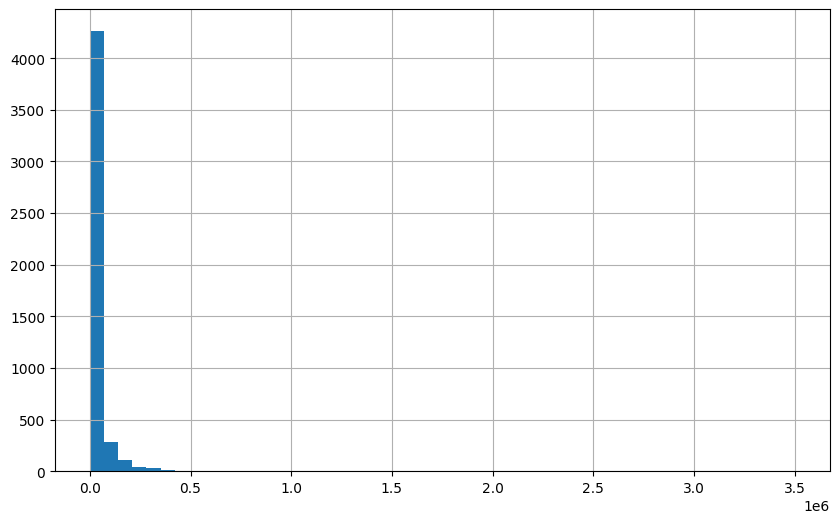

In [165]:
df['Rent'].hist(bins=50, figsize=(10,6)) #target variable distribution
plt.show()

In [166]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix['Rent'].sort_values(ascending=False)

Rent             1.000000
Bathroom         0.423768
Size             0.388522
BHK              0.370550
Total Floors     0.341218
Current Floor    0.322596
Name: Rent, dtype: float64

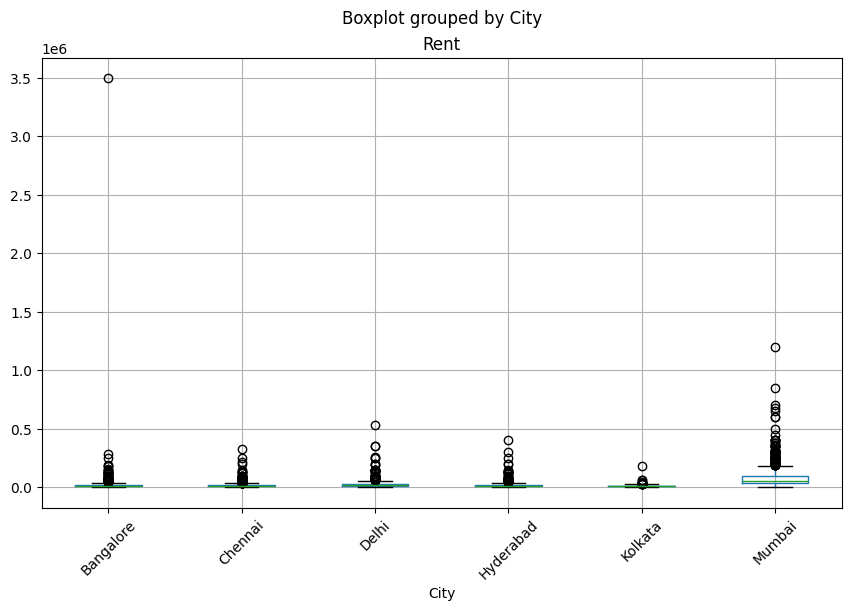

In [167]:
df.boxplot(column='Rent', by='City', figsize=(10,6))
plt.xticks(rotation=45)
plt.show()

In [168]:
df['Rent'].describe() #outliers??
df.nlargest(10, 'Rent')[['City', 'BHK', 'Size', 'Rent']]

,City,BHK,Size,Rent
1834,Bangalore,3.0,2500.0,3500000
999,Mumbai,4.0,NaN,1200000
825,NaN,NaN,3064.0,1000000
1326,Mumbai,4.0,NaN,850000
1456,Mumbai,4.0,3200.0,700000
1481,Mumbai,4.0,1962.0,680000
1316,Mumbai,5.0,NaN,650000
724,Mumbai,4.0,2500.0,600000
790,Mumbai,5.0,3200.0,600000
1381,NaN,5.0,4500.0,600000


In [169]:
df[df['Total Floors'] > 30][['Current Floor', 'Total Floors']]

,Current Floor,Total Floors
530,43.0,78.0
542,17.0,31.0
555,4.0,58.0
559,60.0,66.0
560,34.0,48.0
...,...,...
4457,20.0,35.0
4515,4.0,31.0
4538,1.0,35.0
4570,11.0,35.0


# EDA Summary — Key Findings

- Rent is heavily right-skewed (mean ≫ median); will need log transformation before modeling.
- Numeric features (`Bathroom`, `Size`, `BHK`, `Total Floors`, `Current Floor`) each show **moderate** correlation with `Rent` (0.31–0.43) — no single strong predictor.
- One extreme outlier confirmed: a Bangalore listing (3BHK, 2500 sqft) at ₹3,500,000/month is ~3x the next highest value with no matching size increase 
- High total-floor values (up to 89) are plausible, not a parsing artifact

In [170]:
df.loc[df['Rent'] == df['Rent'].max(), :]

,Posted On,BHK,Size,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,Rent,Current Floor,Total Floors
1834,2022-06-08,3.0,2500.0,Carpet Area,Marathahalli,Bangalore,Semi-Furnished,Bachelors,3.0,Contact Agent,3500000,4.0,4.0


In [171]:
df.loc[df['Rent'] >= 1e6, ['City', 'BHK', 'Size', 'Rent']]

,City,BHK,Size,Rent
825,NaN,NaN,3064.0,1000000
999,Mumbai,4.0,NaN,1200000
1834,Bangalore,3.0,2500.0,3500000


In [172]:
df[df['City'] == 'Bangalore']['Rent'].describe()

count    7.610000e+02
mean     2.567661e+04
std      1.287036e+05
min      3.500000e+03
25%      1.000000e+04
50%      1.450000e+04
75%      2.200000e+04
max      3.500000e+06
Name: Rent, dtype: float64

In [173]:
df.loc[df['Rent'] == 3500000, 'Rent'] = 350000 #assume extra 0

In [174]:
df.loc[df['City'] == 'Bangalore', 'Rent'].describe()

count       761.000000
mean      21537.319317
std       28338.412473
min        3500.000000
25%       10000.000000
50%       14500.000000
75%       22000.000000
max      350000.000000
Name: Rent, dtype: float64

In [175]:
df['Rent'].describe()

count    4.741000e+03
mean     3.432776e+04
std      5.994879e+04
min      1.200000e+03
25%      1.000000e+04
50%      1.600000e+04
75%      3.300000e+04
max      1.200000e+06
Name: Rent, dtype: float64

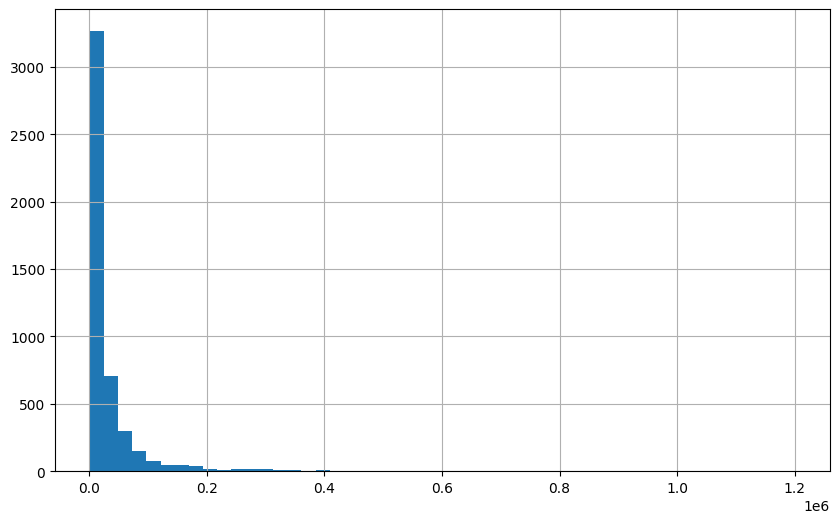

In [176]:
df['Rent'].hist(bins=50, figsize=(10,6))
plt.show()

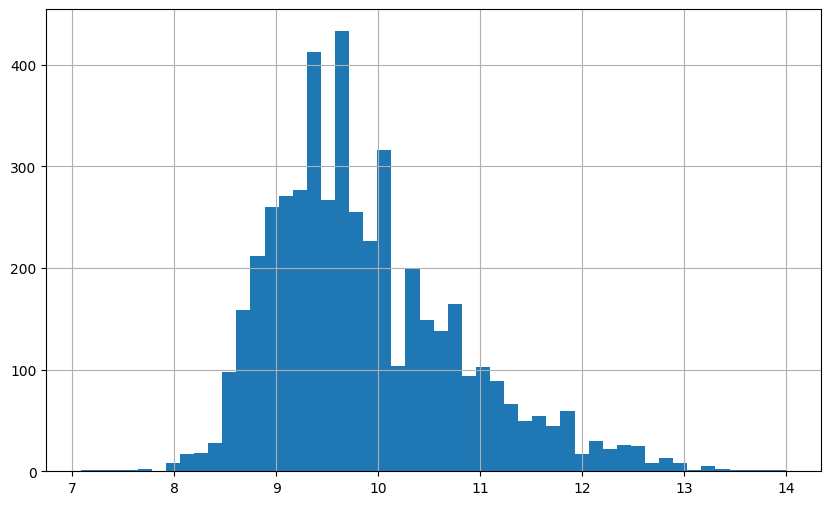

In [177]:
np.log1p(df['Rent']).hist(bins=50, figsize=(10,6))
plt.show()

`Rent` is heavily right-skewed even after outlier correction. Applied `log1p` transformation → distribution becomes approximately bell-shaped.
`Rent_log` will be used as the training target; predictions will be converted back via `expm1()` for final evaluation.

In [178]:
df['Rent_log'] = np.log1p(df['Rent'])

## EDA & Cleaning Summary

- All 11 feature columns had messy text formatting (symbols, extra words, mixed casing) — cleaned each one individually, mostly with regex.
- 5 rows missing 50%+ of their data were dropped.
- Missing values filled per column: some using relationships between columns (BHK ↔ Size, Bathroom via BHK), others with median or mode.
- Found one extreme Rent outlier (Bangalore, ₹3.5M) — confirmed it against a public reference notebook on the same dataset, then corrected it (likely an extra digit).
- Rent was heavily skewed, so we log-transformed it (`Rent_log`) — it'll be used as the training target instead of raw Rent.

Data is now clean and ready for the train/test split.

# Split Train & Test sets
-Relay on BHK col 

In [179]:
from sklearn.model_selection import StratifiedShuffleSplit

In [180]:
df['BHK'].value_counts()

BHK
2.0    1920
1.0     947
3.0     911
4.0     162
5.0      17
6.0       5
Name: count, dtype: int64

In [181]:
strat_col = df['BHK'].fillna(-1)

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(df, strat_col):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]

In [182]:
strat_test_set['BHK'].value_counts() / len(strat_test_set)

BHK
2.0    0.404636
1.0    0.200211
3.0    0.191781
4.0    0.034773
5.0    0.003161
6.0    0.001054
Name: count, dtype: float64

In [183]:
df['BHK'].value_counts() / len(df)

BHK
2.0    0.404978
1.0    0.199747
3.0    0.192154
4.0    0.034170
5.0    0.003586
6.0    0.001055
Name: count, dtype: float64

In [184]:
housing = strat_train_set.drop("Rent_log", axis=1)
housing_labels = strat_train_set["Rent_log"].copy()
#ignore target variable

In [185]:
housing = housing.drop("Rent", axis=1)

In [186]:
housing.info()

<class 'pandas.DataFrame'>
Index: 3792 entries, 3471 to 4206
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Posted On          3251 non-null   datetime64[us]
 1   BHK                3169 non-null   float64       
 2   Size               3001 non-null   float64       
 3   Area Type          3032 non-null   str           
 4   Area Locality      3318 non-null   str           
 5   City               3296 non-null   str           
 6   Furnishing Status  3229 non-null   str           
 7   Tenant Preferred   3261 non-null   str           
 8   Bathroom           3367 non-null   float64       
 9   Point of Contact   3306 non-null   str           
 10  Current Floor      3133 non-null   float64       
 11  Total Floors       3133 non-null   float64       
dtypes: datetime64[us](1), float64(5), str(6)
memory usage: 622.9 KB


# Deep EDA
Train set 

In [187]:
train_copy = housing.copy()
train_copy['Rent_log'] = housing_labels

In [188]:
corr_matrix = train_copy.corr(numeric_only=True)
corr_matrix['Rent_log'].sort_values(ascending=False)

Rent_log         1.000000
Bathroom         0.684068
BHK              0.600982
Size             0.570641
Total Floors     0.544434
Current Floor    0.501980
Name: Rent_log, dtype: float64

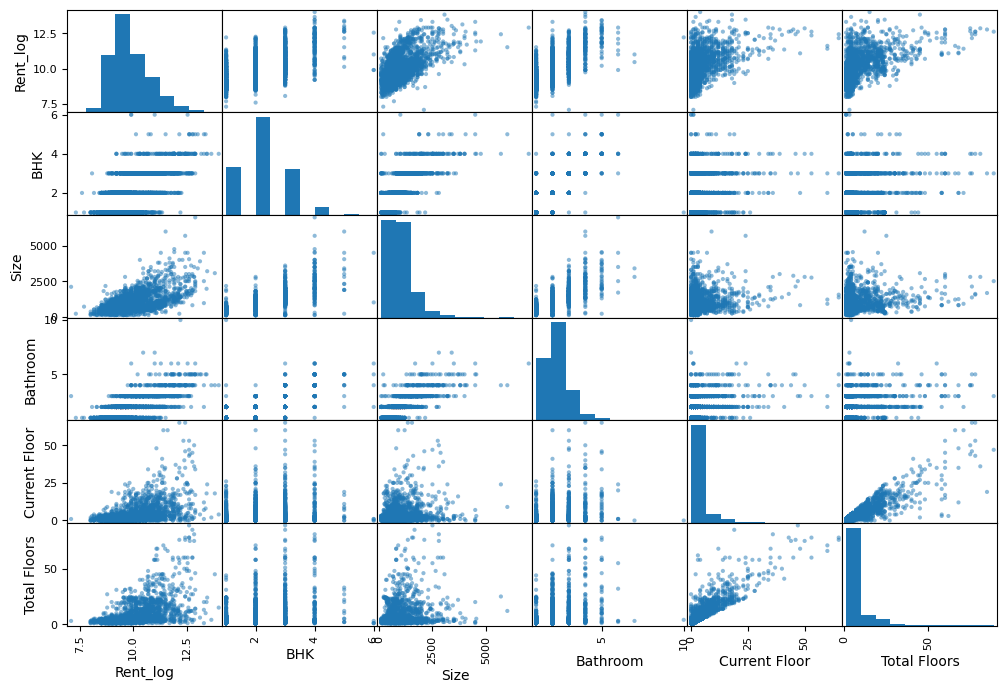

In [189]:
attributes = ['Rent_log', 'BHK', 'Size', 'Bathroom', 'Current Floor', 'Total Floors']
scatter_matrix(train_copy[attributes], figsize=(12, 8))
plt.show()

In [190]:
train_copy['Size_per_BHK'] = train_copy['Size'] / train_copy['BHK']
train_copy['Bathroom_per_BHK'] = train_copy['Bathroom'] / train_copy['BHK']
train_copy['Floor_ratio'] = train_copy['Current Floor'] / train_copy['Total Floors']

In [191]:
corr_matrix = train_copy.corr(numeric_only=True)
corr_matrix['Rent_log'].sort_values(ascending=False)

Rent_log            1.000000
Bathroom            0.684068
BHK                 0.600982
Size                0.570641
Total Floors        0.544434
Current Floor       0.501980
Size_per_BHK        0.231337
Bathroom_per_BHK    0.173252
Floor_ratio         0.140299
Name: Rent_log, dtype: float64

In [192]:
train_copy['Area Locality'].value_counts().head(20)

Area Locality
Bandra West                           31
Gachibowli                            19
Electronic City                       18
Miyapur, NH 9                         15
Medavakkam                            15
Chembur                               15
Kondapur                              15
K R Puram                             13
Velachery                             13
Laxmi Nagar                           13
Chromepet, GST Road                   13
Madipakkam                            12
Vadapalani                            12
Sholinganallur                        12
Andheri West                          12
Perungalathur, Chennai Bypass Road    11
Kukatpally, NH 9                      11
Banjara Hills, NH 9                   11
Salt Lake City Sector 2               11
Ambattur                              10
Name: count, dtype: int64

In [193]:
print('unique train:', train_copy['Area Locality'].nunique())
print('Appered once', (train_copy['Area Locality'].value_counts() == 1).mean())

unique train: 1738
Appered once 0.6726121979286537


In [194]:
train_copy[(train_copy['Floor_ratio'] < 0) | (train_copy['Floor_ratio'] > 1)][['Current Floor', 'Total Floors', 'Floor_ratio']]

,Current Floor,Total Floors,Floor_ratio


# Custom Transformers

In [195]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer



## BHK & Size Cross-Imputer
Cross-imputes missing BHK and Size values using the BHK <-> Size median
relationship. Fit on training data only to avoid leakage.

In [196]:

# class BHKSizeImputer(BaseEstimator, TransformerMixin):
#     def fit(self, X, y=None):
#         self.bhk_size_medians_ = X.groupby('BHK')['Size'].median()
#         self.bhk_fallback_ = X['BHK'].median()
#         self.size_fallback_ = X['Size'].median()
#         return self

#     def transform(self, X):
#         X = X.copy()

#         def impute_bhk(row):
#             if pd.notna(row['BHK']):
#                 return row['BHK']
#             if pd.notna(row['Size']):
#                 diffs = (self.bhk_size_medians_ - row['Size']).abs()
#                 return diffs.idxmin()
#             return self.bhk_fallback_

#         def impute_size(row):
#             if pd.notna(row['Size']):
#                 return row['Size']
#             if pd.notna(row['BHK']) and row['BHK'] in self.bhk_size_medians_.index:
#                 candidate = self.bhk_size_medians_[row['BHK']]
#                 if pd.notna(candidate):
#                     return candidate
#             return self.size_fallback_

#         X['BHK'] = X.apply(impute_bhk, axis=1)
#         X['Size'] = X.apply(impute_size, axis=1)
#         return X

In [197]:
from transformers import BHKSizeImputer, AreaLocalityTargetEncoder

In [198]:
# bhk_size_imputer = BHKSizeImputer()
# housing = bhk_size_imputer.fit_transform(housing)

## Area Locality Target Encoder
Replaces Area Locality with a smoothed mean of Rent_log per locality.
Localities with few rows shrink toward the global mean. Fit on training
data only (needs y).

In [199]:
# class AreaLocalityTargetEncoder(BaseEstimator, TransformerMixin):
#     def __init__(self, smoothing=10):
#         self.smoothing = smoothing

#     def fit(self, X, y):
#         df = X[['Area Locality']].copy()
#         df['target'] = y.values

#         self.global_mean_ = df['target'].mean()

#         stats = df.groupby('Area Locality')['target'].agg(['mean', 'count'])
#         smoothed = (stats['count'] * stats['mean'] + self.smoothing * self.global_mean_) / (stats['count'] + self.smoothing)

#         self.locality_means_ = smoothed
#         return self

#     def transform(self, X):
#         X = X.copy()
#         X['Area Locality'] = X['Area Locality'].map(self.locality_means_).fillna(self.global_mean_)
#         return X

In [200]:
# locality_encoder = AreaLocalityTargetEncoder(smoothing=10)
# housing = locality_encoder.fit_transform(housing, housing_labels)

In [201]:
print(housing['Area Locality'].isna().sum())
housing['Area Locality'].describe()

474


count            3318
unique           1738
top       Bandra West
freq               31
Name: Area Locality, dtype: object

In [202]:
housing.isna().sum()

Posted On            541
BHK                  623
Size                 791
Area Type            760
Area Locality        474
City                 496
Furnishing Status    563
Tenant Preferred     531
Bathroom             425
Point of Contact     486
Current Floor        659
Total Floors         659
dtype: int64

In [203]:
housing = housing.drop('Posted On', axis=1)

# Build the Preprocessing Pipeline

In [204]:
num_attribs = [
    'BHK',
    'Size',
    'Bathroom',
    'Current Floor',
    'Total Floors',
    'Area Locality'
]

cat_attribs = [
    'Area Type',
    'City',
    'Furnishing Status',
    'Tenant Preferred',
    'Point of Contact'
]

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('std_scaler', StandardScaler()),
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

column_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', cat_pipeline, cat_attribs),
])

preprocessing_pipeline = Pipeline([
    ('bhk_size_imputer', BHKSizeImputer()),
    ('locality_encoder', AreaLocalityTargetEncoder(smoothing=10)),
    ('columns', column_pipeline),
])

In [205]:

# num_attribs = ['BHK', 'Size', 'Bathroom', 'Current Floor', 'Total Floors', 'Area Locality']
# cat_attribs = ['Area Type', 'City', 'Furnishing Status', 'Tenant Preferred', 'Point of Contact']

# num_pipeline = Pipeline([
#     ('imputer', SimpleImputer(strategy='median')),
#     ('std_scaler', StandardScaler()),
# ])

# cat_pipeline = Pipeline([
#     ('imputer', SimpleImputer(strategy='most_frequent')),
#     ('onehot', OneHotEncoder(handle_unknown='ignore')),
# ])

# full_pipeline = ColumnTransformer([
#     ('num', num_pipeline, num_attribs),
#     ('cat', cat_pipeline, cat_attribs),
# ])

# housing_prepared = full_pipeline.fit_transform(housing)
# housing_prepared.shape


In [206]:
X_test = strat_test_set.drop(columns=['Rent', 'Rent_log'])
y_test = strat_test_set['Rent_log'].copy()

In [207]:
X_test = X_test.drop('Posted On', axis=1)

In [208]:

# X_test = strat_test_set.drop("Rent", axis=1)
# y_test = strat_test_set["Rent"].copy()
# # X_test = bhk_size_imputer.transform(X_test)
# # X_test = locality_encoder.transform(X_test)
# # X_test_prepared = full_pipeline.transform(X_test)
# # X_test_prepared.shape

The output of full_pipeline is the final numerical feature matrix.
This is the data that will be passed to the ML models.

# Starting the model

In [209]:
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from scipy import stats

In [210]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'SVR': SVR(),
}

In [211]:
# Cross-validate each model (10-fold, on train only)

cv_results = {}

for name, model in models.items():

    model_pipeline = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model', model)
    ])

    scores = cross_val_score(
        model_pipeline,
        housing,
        housing_labels,
        scoring='neg_mean_squared_error',
        cv=10
    )

    mse_scores = -scores
    cv_results[name] = mse_scores

    print(
        f"{name}: mean MSE = {mse_scores.mean():.4f}, "
        f"std = {mse_scores.std():.4f}"
    )

Linear Regression: mean MSE = 0.2248, std = 0.0273
Decision Tree: mean MSE = 0.3764, std = 0.0398
Random Forest: mean MSE = 0.2323, std = 0.0328
SVR: mean MSE = 0.2171, std = 0.0286


In [212]:
# # cross-validate each model (10-fold, on train only)
# cv_results = {} 

# for name, model in models.items():
#     scores = cross_val_score(
#         model, housing_prepared, housing_labels,
#         scoring='neg_mean_squared_error', cv=10
#     )
#     mse_scores = -scores
#     cv_results[name] = mse_scores
#     print(f"{name}: mean MSE = {mse_scores.mean():.4f}, std = {mse_scores.std():.4f}")

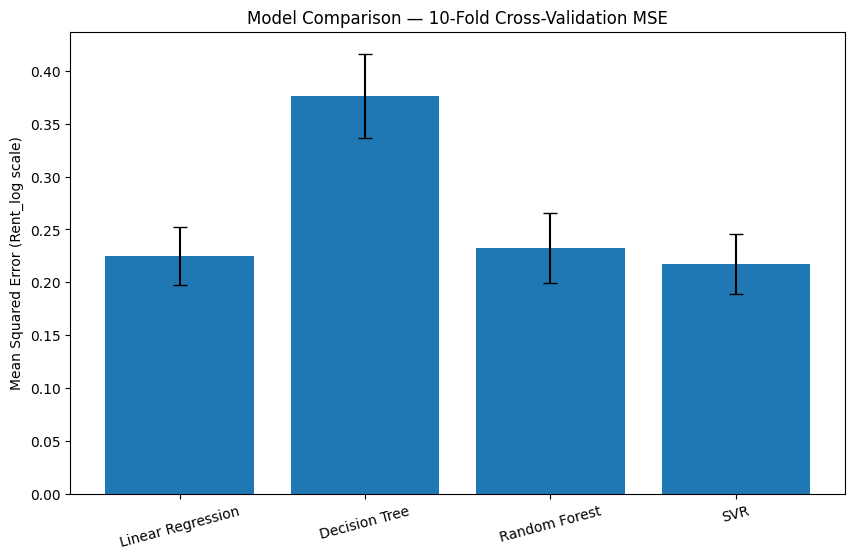

In [213]:
mse_means = [cv_results[name].mean() for name in models]
mse_stds = [cv_results[name].std() for name in models]

plt.figure(figsize=(10, 6))
plt.bar(models.keys(), mse_means, yerr=mse_stds, capsize=5)
plt.ylabel('Mean Squared Error (Rent_log scale)')
plt.title('Model Comparison — 10-Fold Cross-Validation MSE')
plt.xticks(rotation=15)
plt.show()

# Fine-Tune the Best Model (Random Forest)

In [214]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.metrics import mean_squared_error
import joblib

In [215]:
param_grid = [
    {'n_estimators': [50, 100, 200], 'max_features': [0.3, 0.5, 0.7]},
    {'bootstrap': [False], 'n_estimators': [50, 100], 'max_features': [0.3, 0.5]},
]


model_pipeline = Pipeline([
    ('preprocessing', preprocessing_pipeline),
    ('model', RandomForestRegressor(random_state=42))
])

# forest_reg = RandomForestRegressor(random_state=42)
# grid_search = GridSearchCV(
#     forest_reg, param_grid, cv=5,
#     scoring='neg_mean_squared_error',
#     return_train_score=True
# )
# grid_search.fit(housing_prepared, housing_labels)

In [216]:
param_grid = [
    {
        'model__n_estimators': [50, 100, 200],
        'model__max_features': [0.3, 0.5, 0.7]
    },
    {
        'model__bootstrap': [False],
        'model__n_estimators': [50, 100],
        'model__max_features': [0.3, 0.5]
    }
]

In [217]:
grid_search = GridSearchCV(
    model_pipeline,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    return_train_score=True
)

grid_search.fit(housing, housing_labels)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__max_features': [0.3, 0.5, ...], 'model__n_estimators': [50, 100, ...]}, {'model__bootstrap': [False], 'model__max_features': [0.3, 0.5], 'model__n_estimators': [50, 100]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index

In [218]:
param_distribs = {
    'model__n_estimators': randint(low=50, high=300),
    'model__max_features': uniform(loc=0.1, scale=0.9),
    'model__bootstrap': [True, False],
}

model_pipeline = Pipeline([
    ('preprocessing', preprocessing_pipeline),
    ('model', RandomForestRegressor(random_state=42))
])

rnd_search = RandomizedSearchCV(
    model_pipeline,
    param_distributions=param_distribs,
    n_iter=20,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42
)

rnd_search.fit(housing, housing_labels)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__bootstrap': [True, False], 'model__max_features': <scipy.stats....001861B783250>, 'model__n_estimators': <scipy.stats....001861B782990>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``Random

In [219]:
# param_distribs = {
#     'n_estimators': randint(low=50, high=300),
#     'max_features': uniform(loc=0.1, scale=0.9),
#     'bootstrap': [True, False],
# }

# forest_reg = RandomForestRegressor(random_state=42)
# rnd_search = RandomizedSearchCV(
#     forest_reg, param_distributions=param_distribs,
#     n_iter=20, cv=5, scoring='neg_mean_squared_error',
#     random_state=42
# )
# rnd_search.fit(housing_prepared, housing_labels)

In [220]:
print('Best params:', rnd_search.best_params_)
print('Best MSE:', -rnd_search.best_score_)

print(f"GridSearchCV:       MSE = {-grid_search.best_score_:.4f}")
print(f"RandomizedSearchCV: MSE = {-rnd_search.best_score_:.4f}")

Best params: {'model__bootstrap': True, 'model__max_features': np.float64(0.22554447458683766), 'model__n_estimators': 269}
Best MSE: 0.21699831467640934
GridSearchCV:       MSE = 0.2176
RandomizedSearchCV: MSE = 0.2170


# Cross-Validate the Final Model

In [221]:
final_model = grid_search.best_estimator_

# test_predictions = final_model.predict(X_test)


In [222]:
test_predictions = final_model.predict(X_test)
test_mse = mean_squared_error(y_test, test_predictions)
print('Test MSE (log scale):', test_mse)

Test MSE (log scale): 0.18551774569691548


In [223]:
final_scores = cross_val_score(
    final_model,
    housing,
    housing_labels,
    scoring='neg_mean_squared_error',
    cv=10
)

final_mse_scores = -final_scores

print('Scores:', final_mse_scores)
print('Mean MSE:', final_mse_scores.mean())
print('Std:', final_mse_scores.std())

Scores: [0.2088199  0.19275625 0.18082936 0.24794147 0.174718   0.21422267
 0.18698619 0.22235921 0.23208933 0.27036543]
Mean MSE: 0.2131087803911103
Std: 0.029273768163804708


# Evaluate on the Test Set

In [224]:
# test_predictions = final_model.predict(X_test)
# test_mse = mean_squared_error(y_test, test_predictions)
# print('Test MSE (log scale):', test_mse)

In [225]:
X_test = strat_test_set.drop(columns=['Rent', 'Rent_log'])
y_test = strat_test_set['Rent_log'].copy()

In [226]:
# Refit and save each baseline model
for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model', model)
    ])
    pipeline.fit(housing, housing_labels)
    filename = name.lower().replace(' ', '_') + '.pkl'
    joblib.dump(pipeline, filename)
    print(f'Saved {filename}')

# Save the tuned models
joblib.dump(final_model, "random_forest_house_rent.pkl")        # grid_search best
joblib.dump(rnd_search.best_estimator_, "random_forest_rnd_search.pkl")

Saved linear_regression.pkl
Saved decision_tree.pkl
Saved random_forest.pkl
Saved svr.pkl


['random_forest_rnd_search.pkl']